# Introduction to Machine Learning — Class 1
## Understanding and Preparing Data

**Dataset:** Adult / Census Income (tabular)

---

### Learning goals
By the end of this notebook, you should be able to:
- Load and inspect a dataset
- Identify different data types
- Perform descriptive analysis
- Detect missing values and inconsistencies
- Make justified feature selection decisions
- Save a cleaned dataset for the next class

> **Mindset:** There is rarely a single “correct” cleaning pipeline.  
> Your decisions must be **reasoned**, **documented**, and **reproducible**.


<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>

## 0. Setup (dataset file)

Place the dataset file in the **same folder** as this notebook.

Expected filename: `adult.csv`

Adjust the path/filename below accordingly.


In [2]:
DATA_PATH = "adult.csv"


## 1. Tools and Libraries

### Task
Import libraries for:
- numerical computing
- data handling
- visualisation

**Guiding questions**
- When do you prefer NumPy arrays vs Pandas DataFrames? \
NumPy is for homogeneous data and it's used for low overhead and heavy maths needed. \
Pandas DataFrames are for heterogeneous and categorised data and it is best for grouping and strucring data. \

- Why separate data manipulation from plotting? \
Manipulation refers to the clean, transform and aggregate data. \
Ploting refers to visualize data. \
Keep them separate is a more modular approach to the problem.

In [3]:
# TODO: import required libraries (numpy, pandas, seaborn, matplotlib)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Auto-check (do not edit)
import importlib
_required = ["numpy", "pandas", "seaborn", "matplotlib"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed: required packages available.")


Auto-check passed: required packages available.


## 2. Load the dataset

### Tasks
1. Load the dataset into a DataFrame `df`
2. Show the first 5 rows
3. Print the dataset shape `(rows, cols)`

**Questions (answer in Markdown)**
- How many rows and columns? \
48842 rows and 15 columns.
- What does one row represent? \
Single individual record data 


In [5]:
# TODO: load CSV into df
df = pd.read_csv(DATA_PATH)
display(df.head())
print(df.shape)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


(48842, 15)


In [6]:
# Auto-check (do not edit)
import pandas as pd
assert "df" in globals(), "You must create a DataFrame named df."
assert isinstance(df, pd.DataFrame), "df must be a pandas DataFrame."
assert df.shape[0] > 1000 and df.shape[1] >= 10, "df shape looks suspicious (check you loaded the right file)."
print("Auto-check passed: df exists and seems plausible.")


Auto-check passed: df exists and seems plausible.


## 3. First inspection

### Tasks
- Print column names
- Use `df.info()` to inspect data types and non-null counts
- Use `df.describe()` for numerical summary

**Guiding questions**
- Are all columns numeric?
Nah uh.
- Do the automatic dtypes match the real meaning of the variables? \
Sometimes. May need manual ajustment.


In [7]:
# TODO: inspection
print(df.columns)
df.info()
df.describe(include="all")


Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,48842,4.884200e+04,48842,48842.000000,48842,48842,48842,48842,48842,48842.000000,48842.000000,48842.000000,48842,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


## 4. Identify variable types (conceptual)

### Task
Create lists:
- `numerical_cols`
- `categorical_cols`

**Hints**
- Use `df.dtypes`
- Consider whether some numbers are actually categories (e.g., codes)

**Reflection**
- Why does variable type influence preprocessing and modelling? \
Numeric and Categorical are preprocessed and modelled differently. \
Numeric allows normalization, regression and distance-based analysis. \
Categorical needs encoding for further analysis.

In [8]:
# TODO: define your column groups
numerical_cols = df.select_dtypes(include=['int64']).columns.tolist()
# numerical_cols = [c for c in df.columns if df[c].dtype == "int64"]
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [9]:
# Auto-check (do not edit)
assert isinstance(numerical_cols, list) and isinstance(categorical_cols, list), "numerical_cols and categorical_cols must be lists."
assert len(numerical_cols) + len(categorical_cols) >= 10, "You likely did not classify enough columns."
overlap = set(numerical_cols).intersection(set(categorical_cols))
assert not overlap, f"Columns appear in both lists: {overlap}"
print("Auto-check passed: variable groups defined.")


Auto-check passed: variable groups defined.


## 5. Descriptive analysis

### Numerical variables
- Use `describe()` for your `numerical_cols`
- Plot at least **2 distributions** (histogram) and **1 boxplot**

### Categorical variables
- Show value counts for at least **2 categorical variables**
- Plot at least **1 countplot**

**Guiding questions**
- Are variables on comparable scales?
- Do you see skewness or outliers?


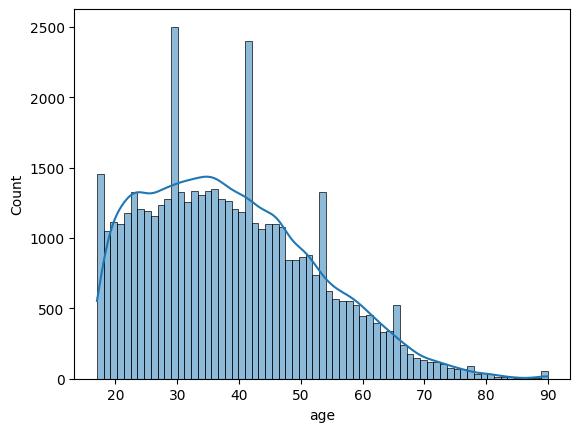

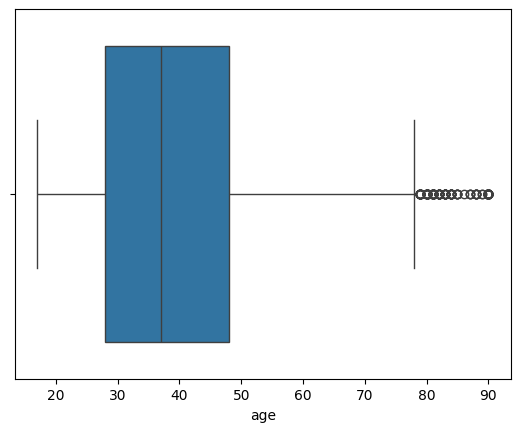

In [10]:
# TODO: numerical summaries and plots
# Examples:
df[numerical_cols].describe()
sns.histplot(x=df[numerical_cols[0]], kde=True)
plt.show()
sns.boxplot(x=df[numerical_cols[0]])
plt.show()


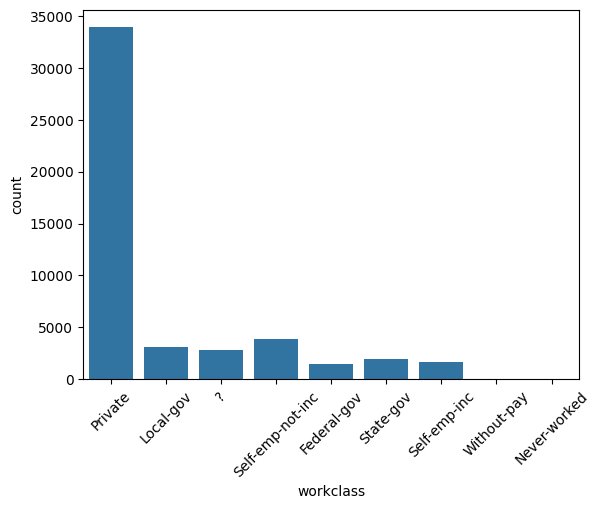

In [11]:
# TODO: categorical summaries and plots
# Examples:
df[categorical_cols[0]].value_counts()
sns.countplot(data=df, x=categorical_cols[0])
plt.xticks(rotation=45)
plt.show()


## 6. Missing values and inconsistencies

In this dataset, missing values may appear as **"?"**.

### Tasks
1. Count occurrences of `"?"` in each column
2. Replace `"?"` with proper missing values (`NaN`)
3. Recount missing values per column using `isna().sum()`

**Reflection**
- Are missing values concentrated in specific variables?
- What could cause missingness in a census dataset?


In [12]:
# TODO: find occurrences of "?"
# Hints:
(df.astype(str) == "?").sum().sort_values(ascending=False)

# TODO: replace "?" with NaN
df = df.replace("?", np.nan)

# TODO: show missing value counts
df.isna().sum().sort_values(ascending=False)


occupation         2809
workclass          2799
native-country      857
age                   0
fnlwgt                0
education             0
educational-num       0
marital-status        0
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

In [13]:
# Auto-check (do not edit)
import numpy as np
q_counts = (df.astype(str) == "?").sum()
assert int(q_counts.sum()) == 0, 'There are still "?" values. Replace them with NaN.'
print('Auto-check passed: no "?" remains in df.')


Auto-check passed: no "?" remains in df.


## 7. Feature selection: first decisions (justify!)

### Task
Create a cleaned version of your dataset called `df_v1` by:
- removing features you believe are **redundant**, **non-informative**, or **problematic**
- documenting **each decision** in Markdown

**Important**
- Do not remove the target variable yet (if present in your dataset).
- Prefer a *small number of well-justified removals* over many arbitrary ones.

Write your justification below.


### Justification log
- Feature removed: educational-num | Reason: It is perfectly correlated with education (deterministic mapping). Keeping both introduces redundancy and multicollinearity.
- Feature removed: fnlwgt | Reason: It does not represent an intrinsic attribute of the individual.



In [20]:
# TODO: create df_v1 from df
# Example:
df_v1 = df.drop(columns=['fnlwgt'])

In [17]:
# Auto-check (do not edit)
assert "df_v1" in globals(), "You must create df_v1."
assert isinstance(df_v1, pd.DataFrame), "df_v1 must be a pandas DataFrame."
assert df_v1.shape[0] == df.shape[0], "Do not remove rows yet in this session; keep the same number of rows."
assert df_v1.shape[1] <= df.shape[1], "df_v1 should have same or fewer columns than df."
print("Auto-check passed: df_v1 created with consistent row count.")


Auto-check passed: df_v1 created with consistent row count.


## 8. Save final dataset for next class

### Final task
Save your `df_v1` to disk using:
- CSV (`adult_clean_v1.csv`)

Also print:
- the saved file name
- the final shape of your dataset

This file will be used in **Class 2**.


In [22]:
# TODO: save df_v1 to disk
# Option A (CSV):
df_v1.to_csv("adult_clean_v1.csv", index=False)
print("Saved:", "adult_clean_v1.csv", "| Shape:", df_v1.shape)


Saved: adult_clean_v1.csv | Shape: (48842, 14)


In [19]:
# Auto-check (do not edit)
import os
ok = os.path.exists("adult_clean_v1.csv") or os.path.exists("adult_clean_v1.parquet")
assert ok, "You must save adult_clean_v1.csv or adult_clean_v1.parquet in the notebook folder."
print("Auto-check passed: cleaned dataset saved.")


Auto-check passed: cleaned dataset saved.


## 9. Wrap-up reflection (answer in Markdown)

- Which decisions were straightforward? Which were subjective? \
Removing fnlwgt → Clearly a sampling weight, not a personal attribute. It does not represent an intrinsic socioeconomic characteristic and is typically excluded in predictive modelling contexts.
- What information would you like to have before making stronger cleaning decisions?
- How could cleaning choices affect downstream modelling and fairness?
